In [1]:
import cvxpy as cp
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import zap
from zap.importers.pypsa import load_pypsa_network, parse_buses
import os
from pathlib import Path
import pypsa
from zap.devices import ACLine
import pandas as pd
import geopandas as gpd
from copy import deepcopy

In [2]:
LOAD_SCALING_FACTOR = 1.27
GEN_SCALING_FACTOR = 1.24
# GEN_SCALING_FACTOR = 1
LINE_SCALING_FACTOR = 0.9
# INVESTMENT_NODE_CANDS = [32, 82, 50, 18, 15, 22, 43, 14, 23, 20, 94, 65, 78] # This is already sorted by land cost
# INVESTMENT_NODE_CANDS = [0, 82, 50, 18, 15, 22, 43, 14, 23, 20, 45, 65, 78] # This is already sorted by land cost
INVESTMENT_NODE_CANDS=[32, 78, 14, 59]

In [3]:
def upsample_zap_devices(devices, factor=4, original_timesteps=24):
    """Upsample time-varying attributes of zap devices by repeating each timestep."""
    upsampled_zap_devices = []
    for dev in devices:
        upsampled_dev = dev.sample_time(original_timesteps*factor, original_timesteps)
        upsampled_zap_devices.append(upsampled_dev)

    return upsampled_zap_devices

In [5]:
HOME_PATH = os.environ.get("HOME")
PYPSA_NETW0RK_PATH = (
    HOME_PATH + "/zap_data/pypsa-networks/western_small/network_2023.nc"
)
pn = pypsa.Network(PYPSA_NETW0RK_PATH)
snapshots = pn.generators_t.p_max_pu.index
# snapshot_data = snapshots[5616:5640]  # 8/23/21 # hourly
snapshot_data = snapshots[5448:5472]  # 8/16/21 # hourly

INFO:pypsa.io:Imported network network_2023.nc has buses, carriers, generators, lines, links, loads, storage_units


## Get terminal/bus cost information for possible investment candidate nodes

In [6]:
buses, buses_to_index = parse_buses(pn) # buses_to_index is dict of "pyspa_bus_name": "zap_terminal"
index_to_bus = {idx: name for name, idx in buses_to_index.items()}
pypsa_bus_names = [index_to_bus[i] for i in INVESTMENT_NODE_CANDS]

b = pn.buses.copy()
gdf = gpd.GeoDataFrame(
    b, geometry=gpd.points_from_xy(b["x"], b["y"]), crs="EPSG:4326"
)

county_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
counties = gpd.read_file(county_url)[["STATEFP","COUNTYFP","GEOID","NAME","STATE_NAME","geometry"]]

j = gpd.sjoin(gdf, counties.to_crs("EPSG:4326"), how="left", predicate="within")

pn.buses["county_fips"] = j["GEOID"]  # 5-digit FIPS
pn.buses["county_name"] = j["NAME"]
pn.buses["state_fips"]  = j["STATEFP"]
pn.buses["state_name"]  = j["STATE_NAME"]

selected_node_fips = pn.buses.loc[pypsa_bus_names, "county_fips"]
county_land_lut_df = pd.read_csv("county_land_lut.csv")

In [7]:
sel = selected_node_fips.rename("county_fips").to_frame()
bus_to_terminal = {bus: term for term, bus in index_to_bus.items()}
sel["terminal"] = sel.index.map(bus_to_terminal)
sel["county_fips"] = sel["county_fips"].astype(str).str.zfill(5)
county_land_lut_df["county_fips"] = county_land_lut_df["county_fips"].astype(str).str.zfill(5)

sel = sel.merge(
    county_land_lut_df,
    left_on="county_fips",
    right_on="county_fips",
    how="left",
)

terminal_cost = (
    sel.groupby("terminal")["land_usd2017_per_acre"]
      .first()   # or .mean(), depending on what you want
      .sort_index()
)

In [8]:
sel.head(15)

,county_fips,terminal,land_usd2017_per_acre,land_usd2026_per_acre,annualized_land_usd2026_acre
0,32001,32,207.092794,275.433416,25.998966
1,41059,78,983.423396,1307.953117,123.461521
2,06065,14,522.828450,695.361839,65.637238
3,04017,59,828.911713,1102.452579,104.063724


In [9]:
CAPITAL_COSTS = np.array(sel.land_usd2017_per_acre)

In [10]:
CAPITAL_COSTS

array([207.0927941, 983.423396 , 522.8284502, 828.9117132])

## Convert PyPSA network to Zap

In [11]:
pypsa_kwargs = {}
pypsa_net, pypsa_devices = load_pypsa_network(
    pn, snapshot_data, power_unit=1.0e3, cost_unit=100.0, **pypsa_kwargs
)

pypsa_devices = upsample_zap_devices(pypsa_devices, factor=4, original_timesteps=24)

Dropping empty generators.


## Helper to create devices for planning problem

In [12]:
def create_planning_devices(pypsa_devices, planning_devices_params_dict):
    num_nodes = planning_devices_params_dict["num_nodes"]
    investment_node_cands = planning_devices_params_dict["investment_node_cands"]
    gen_scaling_factor = planning_devices_params_dict["gen_scaling_factor"]
    load_scaling_factor = planning_devices_params_dict["load_scaling_factor"]
    line_scaling_factor = planning_devices_params_dict["line_scaling_factor"]
    dc_nominal_capacity = planning_devices_params_dict["dc_nominal_capacity"]
    capital_costs = planning_devices_params_dict["capital_costs"]
    workload_profile = planning_devices_params_dict["workload_profile"]
    pypsa_net = planning_devices_params_dict["pypsa_net"]
    pypsa_devices = planning_devices_params_dict["pypsa_devices"]

    pypsa_devices_dc = deepcopy(pypsa_devices)

    # Scale load, gen, and line capacities
    pypsa_devices_dc[1].load *= load_scaling_factor
    pypsa_devices_dc[0].dynamic_capacity *= gen_scaling_factor
    pypsa_devices_dc[3].nominal_capacity *= line_scaling_factor
    pypsa_devices_dc[3].nominal_capacity[168] = 0.5
    pypsa_devices_dc[3].nominal_capacity[176] = 0.5
    pypsa_devices_dc[3].nominal_capacity[49] = 0.3

    # Select which nodes to build at
    dc_terminals = np.array(investment_node_cands[:num_nodes])
    n_dc = len(dc_terminals)
    dc_capital_costs = capital_costs[:n_dc]

    # Build nominal capacities for DC loads
    if np.isscalar(dc_nominal_capacity):
        nominal_capacity = np.full(n_dc, dc_nominal_capacity)
    else:
        nominal_capacity = dc_nominal_capacity

    # Build DCLoad object
    dcloads = zap.DataCenterLoad(
        num_nodes=pypsa_net.num_nodes,
        terminal=dc_terminals,
        profiles=n_dc*[workload_profile],
        nominal_capacity=nominal_capacity,
        linear_cost=np.ones(n_dc) * 0,
        settime_horizon=96,
        capital_cost=dc_capital_costs
    )

    pypsa_devices_dc.append(dcloads)
    return pypsa_devices_dc


## Run and analyze single node injection

In [13]:
def node_price_summaries(prices, topk=5, q=(0.95, 0.99)):
    """
    prices: [N,T]
    Returns dict of [N,] summaries over time for each node.
    """
    prices = np.asarray(prices)

    out = {}
    # percentiles over time (axis=1)
    for qq in q:
        out[f"p{int(qq*100)}"] = np.quantile(prices, qq, axis=1)

    # mean over time
    out["mean"] = prices.mean(axis=1)

    # mean of top-k hours (per node)
    k = int(topk)
    out[f"mean_top{k}"] = np.sort(prices, axis=1)[:, -k:].mean(axis=1)

    # max (what you're already doing)
    out["max"] = prices.max(axis=1)

    return out


In [15]:
# This will add a DC at the cheapest land cost node
planning_devices_params_dict = {
    "num_nodes": 1,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": 2.25, # GW
    "capital_costs": CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}


planning_devices = create_planning_devices(pypsa_devices, planning_devices_params_dict)
base_outcome = pypsa_net.dispatch(
    planning_devices[:-1], time_horizon=96, solver=cp.CLARABEL, add_ground=False
)
single_node_outcome = pypsa_net.dispatch(
    planning_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

Dispatch Cost before injection: 2228.5776770665034
Dispatch Cost after injection: 2279.0714021274034
Dispatch Cost Increased by 2.27%


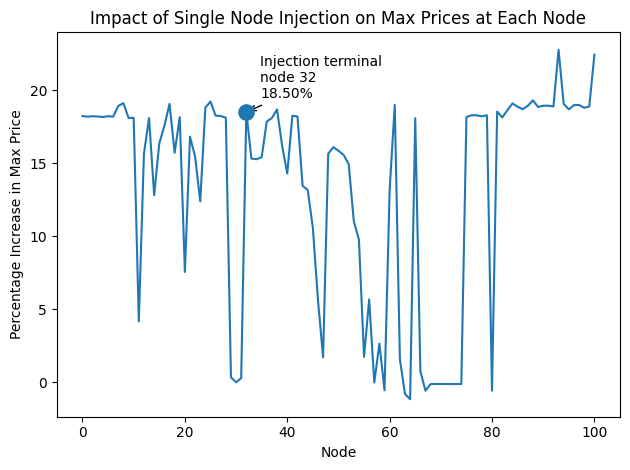

In [16]:
## Analyze results between base outcome and single node injection outcome 

base_outcome_dispatch_cost = base_outcome.problem.value
single_node_outcome_dispatch_cost = single_node_outcome.problem.value

base_outcome_max_prices = base_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
single_node_outcome_max_prices = single_node_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
max_prices_diff_pct = (single_node_outcome_max_prices - base_outcome_max_prices) / base_outcome_max_prices * 100 # [101,] percentage increase in max price at each node

## Observe some results from the dispatch outcome
print(f"Dispatch Cost before injection: {base_outcome_dispatch_cost}")
print(f"Dispatch Cost after injection: {single_node_outcome_dispatch_cost}")
print(f"Dispatch Cost Increased by {(single_node_outcome_dispatch_cost - base_outcome_dispatch_cost)/base_outcome_dispatch_cost * 100:.2f}%")

injection_terminal = INVESTMENT_NODE_CANDS[0]
plt.plot(max_prices_diff_pct, label="Percentage Increase in Max Price at Each Node")
plt.scatter(
    injection_terminal,
    max_prices_diff_pct[injection_terminal],
    s=120,
    zorder=5,
    label=f"Injection terminal (node {injection_terminal})"
)
plt.annotate(
    f"Injection terminal\nnode {injection_terminal}\n{max_prices_diff_pct[injection_terminal]:.2f}%",
    (injection_terminal, max_prices_diff_pct[injection_terminal]),
    xytext=(10, 10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)
plt.xlabel("Node")
plt.ylabel("Percentage Increase in Max Price")
plt.title("Impact of Single Node Injection on Max Prices at Each Node")
plt.tight_layout()

In [78]:
def line_util_metrics(flows_a, flows_b, line_nom_caps, thr=0.90):
    """
    Simple line-util comparison between scenario A and B.

    Args:
        flows_a: [L,T] line flows for scenario A
        flows_b: [L,T] line flows for scenario B
        line_nom_caps: [L,] nominal capacities
        thr: threshold for "critical" / near-binding (e.g., 0.90 or 0.95)

    Returns (dict):
        util_a, util_b: [L,T] utilizations
        peak_a, peak_b: [L]
        d_peak:         [L] = peak_a - peak_b   (positive => A has higher peak)
        hours_a, hours_b: [L] count of hours util>=thr
        d_hours:        [L] = hours_a - hours_b (positive => A has more near-binding hours)
        overload_a, overload_b: [L] mean exceedance above thr
        d_overload:     [L] = overload_a - overload_b
    """
    flows_a = np.asarray(flows_a)
    flows_b = np.asarray(flows_b)
    caps = np.asarray(line_nom_caps).reshape(-1)

    assert flows_a.shape == flows_b.shape
    L, T = flows_a.shape
    assert caps.shape[0] == L

    util_a = np.abs(flows_a) / caps[:, None]
    util_b = np.abs(flows_b) / caps[:, None]

    peak_a = util_a.max(axis=1)
    peak_b = util_b.max(axis=1)
    d_peak = peak_a - peak_b

    hours_a = (util_a >= thr).sum(axis=1)
    hours_b = (util_b >= thr).sum(axis=1)
    d_hours = hours_a - hours_b

    overload_a = np.maximum(util_a - thr, 0.0).mean(axis=1)
    overload_b = np.maximum(util_b - thr, 0.0).mean(axis=1)
    d_overload = overload_a - overload_b

    return {
        "util_a": util_a, "util_b": util_b,
        "peak_a": peak_a, "peak_b": peak_b, "d_peak": d_peak,
        "hours_a": hours_a, "hours_b": hours_b, "d_hours": d_hours,
        "overload_a": overload_a, "overload_b": overload_b, "d_overload": d_overload,
        "thr": thr
    }

def critical_lines_from_base(base_flows, single_flows, line_nom_caps, thr=0.90):
    """
    Step 1: define critical lines as those that become near-binding in the single-node case.
    We flag lines with peak utilization >= thr under single-node.

    Returns:
        crit_idx: indices of critical lines
        metrics: output of line_util_metrics(single, base, ...)
    """
    metrics = line_util_metrics(single_flows, base_flows, line_nom_caps, thr=thr)
    crit_idx = np.where(metrics["peak_a"] >= thr)[0]  # peak_a is single-node peak
    return crit_idx, metrics

In [79]:
##--- Usage ---##
line_nom_caps = planning_devices[3].nominal_capacity.squeeze()
single_flows  = single_node_outcome.power[3][1]   # [251,96]
base_flows    = base_outcome.power[3][1]          # [251,96]

crit_idx, single_vs_base = critical_lines_from_base(
    base_flows=base_flows,
    single_flows=single_flows,
    line_nom_caps=line_nom_caps,
    thr=0.90
)

print("num critical lines:", len(crit_idx))
# Now later you can evaluate distributed vs single (or distributed vs base) using line_util_metrics(...)
# dist_flows = dist_outcome.power[3][1]
# dist_vs_single = line_util_metrics(single_flows, dist_flows, line_nom_caps, thr=0.90)
# and then look at dist_vs_single["d_peak"][crit_idx], etc.


num critical lines: 11


In [80]:
single_vs_base['d_hours']

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5,  0,
        0,  0,  0,  0,  0,  0, -8,  0,  0,  0, -9,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [81]:
line_nom_caps = planning_devices[3].nominal_capacity.squeeze() # [251,]
single_node_outcome_line_flows = single_node_outcome.power[3][1] # [251, 96]
single_node_line_util = np.abs(single_node_outcome_line_flows) / line_nom_caps[:, None]  # (251, 96) utilization in [0, inf)

base_outcome_line_flows = base_outcome.power[3][1] # [251, 96]
base_line_util = np.abs(base_outcome_line_flows) / line_nom_caps[:, None]  # (251, 96) utilization in [0, inf)

max_util_per_line = single_node_line_util.max(axis=1) # (251,)
mean_util_per_line = single_node_line_util.mean(axis=1) # (251,)
frac_congested = (single_node_line_util >= 1.0).mean()

print(frac_congested)

0.0


0.11608199999999999

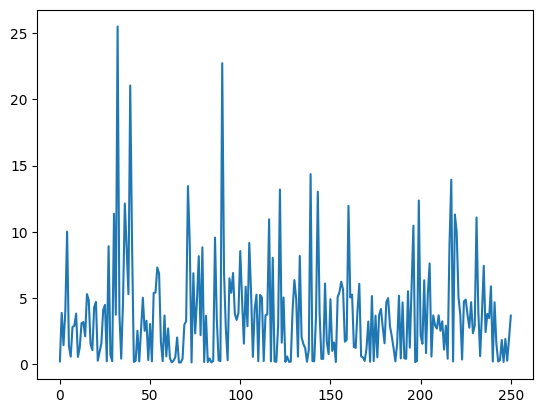

In [82]:
plt.plot(line_nom_caps)
min(line_nom_caps)

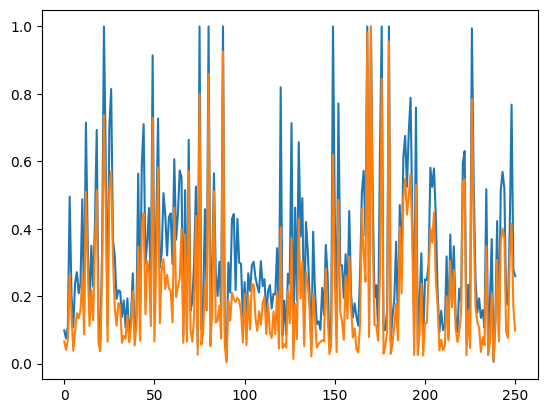

In [83]:
## Analyze line limits or something 
plt.plot(max_util_per_line)
plt.plot(mean_util_per_line)

## Helper to run planning instance

In [21]:
def run_planning_experiment(pypsa_net, pypsa_devices_dc, planning_exp_params_dict):
    total_dc_budget = planning_exp_params_dict["total_dc_budget"]
    dc_lower_bound = planning_exp_params_dict["dc_lower_bound"]
    dc_upper_bound = planning_exp_params_dict["dc_upper_bound"] 
    op_obj_selector = planning_exp_params_dict["op_obj_selector"]
    lmp_metric = planning_exp_params_dict.get("lmp_metric", "meanmax")
    lmp_beta = planning_exp_params_dict.get("lmp_beta", 1.0)
    num_iters = planning_exp_params_dict["num_iters"]

    n_dc = len(pypsa_devices_dc[-1].terminals)

    # Create dispatch layer
    xstar = zap.DispatchLayer(
        pypsa_net,
        pypsa_devices_dc,
        parameter_names={"dc_capacity": (5, "nominal_capacity")},
        time_horizon=96,
        solver=cp.CLARABEL,
    )

    lower_bounds = {"dc_capacity": 0.0}
    upper_bounds = {"dc_capacity": total_dc_budget}

    # Initialize capacities eta randomly within bounds
    # init_eta = np.random.rand(n_dc).clip(dc_lower_bound, dc_upper_bound)
    init_eta = np.full(n_dc, total_dc_budget / n_dc)
    # init_eta = np.zeros(n_dc)
    # init_eta[0] = total_dc_budget
    print(init_eta)
    eta = {"dc_capacity": init_eta}

    # Create objectives
    inv_obj = zap.planning.InvestmentObjective(pypsa_devices_dc, xstar)
    if op_obj_selector == "dispatch":
        op_obj = zap.planning.DispatchCostObjective(pypsa_net, pypsa_devices_dc)
    elif op_obj_selector == "lmp":
        op_obj = zap.planning.LMPObjective(pypsa_net, pypsa_devices_dc, lmp_metric=lmp_metric, lmp_beta = lmp_beta)

    P = zap.planning.PlanningProblem(
        operation_objective=op_obj,
        investment_objective=inv_obj,
        layer=xstar,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
    )

    P.extra_projections = {
        "dc_capacity": zap.planning.SimplexBudgetProjection(
            budget=total_dc_budget, strict=True
        )
    }

    cost = P(**eta, requires_grad=True)
    grad = P.backward()

    state = P.solve(num_iterations=num_iters, initial_state=eta)
    

    return state, P

In [85]:
def run_planning_experiment_benders(pypsa_net, pypsa_devices_dc, planning_exp_params_dict):
    total_dc_budget = planning_exp_params_dict["total_dc_budget"]
    dc_lower_bound = planning_exp_params_dict["dc_lower_bound"]
    dc_upper_bound = planning_exp_params_dict["dc_upper_bound"] 
    capital_cost = planning_exp_params_dict["capital_cost"]

    n_dc = len(pypsa_devices_dc[-1].terminals)
    dc_capital_costs = capital_cost[:n_dc]

    # Create dispatch layer
    xstar = zap.DispatchLayer(
        pypsa_net,
        pypsa_devices_dc,
        parameter_names={"dc_capacity": (5, "nominal_capacity")},
        time_horizon=96,
        solver=cp.CLARABEL,
    )

    lower_bounds = {"dc_capacity": np.full(n_dc, dc_lower_bound)}
    upper_bounds = {"dc_capacity": np.full(n_dc, dc_upper_bound)}

    # Initialize capacities eta randomly within bounds
    init_eta = None
    B = zap.planning.BendersSolver(
        layer=xstar,
        capital_cost=dc_capital_costs,
        budget=total_dc_budget,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        dispatch_scalar=1.0,
    )

    state = B.solve(initial_u=init_eta, max_iter=100, tol=1e-6)
    

    return state

## Run a planning experiment

In [42]:
num_nodes = 4

# ptdf_cands = [43, 45, 40, 39, 38, 18, 37, 44, 82, 52]
# new_cands = [17, 82, 83, 95, 60, 53, 56, 89, 2, 0]
# new_cands = [29, 8, 27, 2, 83, 6, 45, 82, 0, 15]
# new_cands = [29, 31, 13, 11, 56, 24, 7, 30, 20, 58]

planning_devices_params_dict = {
    "num_nodes": num_nodes,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": 2.25, # Doesn't actually matter for planning since we optimize over it 
    "capital_costs": 0*CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    # "workload_profile": "load_profiles/marconi_day_avg.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}
pypsa_devices_dc = create_planning_devices(pypsa_devices, planning_devices_params_dict)

planning_exp_params_dict = {
    "total_dc_budget": 2.25, # GW
    "dc_lower_bound": 0.0, # GW
    "dc_upper_bound": 2.25, # GW
    "op_obj_selector": "lmp", # "dispatch" or "lmp" or "line_util" or "delta_line_util" which defaults to meanmax
    "lmp_metric": "sumsmoothmax",
    "lmp_beta": 1000.0,
    "num_iters": 10
}

planning_state, P = run_planning_experiment(pypsa_net, pypsa_devices_dc, planning_exp_params_dict)

[0.5625 0.5625 0.5625 0.5625]

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>
[0]

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>
Starting iteration 1
{'dc_capacity': tensor([6.0834, 5.8230, 3.2200, 2.3581], dtype=torch.float64)}
{'dc_capacity': tensor([ 1.7122,  1.4519, -1.1511, -2.0130], dtype=torch.float64)}
[0]

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>
{'dc_ca

In [46]:
# Simulate the dispatch outcome with the planned DC capacities
planned_dc_capacities = planning_state[0]["dc_capacity"]
# planned_dc_capacities = np.array([0.21, 0.06, 0.12, 0.09, 0.05, 0.14, 0.07, 0.08, 0.10, 0.08])

# ptdf_cands = [43, 45, 40, 39, 38, 18, 37, 44, 82, 52]
# new_cands = [17, 82, 83, 95, 60, 53, 56, 89, 2, 0]
# new_cands = [29, 8, 27, 2, 83, 6, 45, 82, 0, 15]
# new_cands = [29, 31, 13, 11, 56, 24, 7, 30, 20, 58]

planning_devices_params_dict = {
    "num_nodes": num_nodes,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": planned_dc_capacities, 
    "capital_costs": CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    # "workload_profile": "load_profiles/marconi_day_avg.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}

planned_devices = create_planning_devices(pypsa_devices, planning_devices_params_dict)
distributed_outcome = pypsa_net.dispatch(
    planned_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

Dispatch Cost before injection: 2228.5776770665034
Dispatch Cost after distributed DC: 2274.5791273970053
Dispatch Cost Increased by 2.06%
[0.28879556 0.33750825 0.27337876 1.35031743]


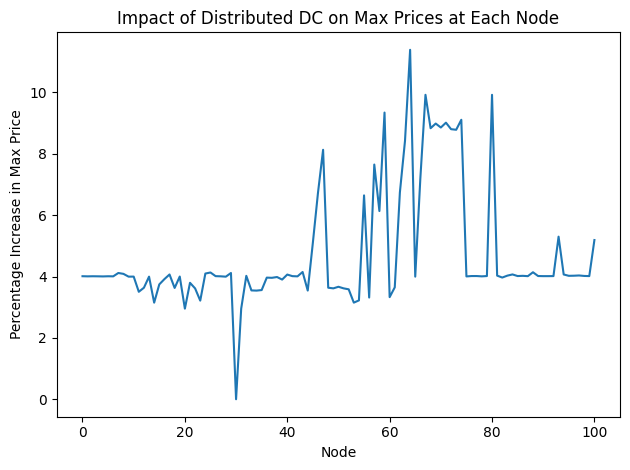

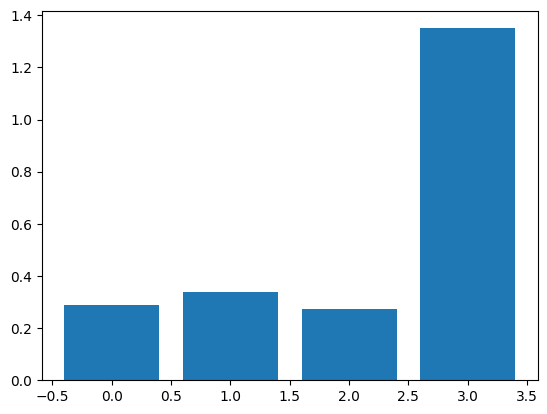

In [47]:
## Analyze results between base outcome and distributed case

base_outcome_dispatch_cost = base_outcome.problem.value
distributed_outcome_dispatch_cost = distributed_outcome.problem.value

base_outcome_max_prices = base_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
distributed_outcome_max_prices = distributed_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
max_prices_diff_pct = (distributed_outcome_max_prices - base_outcome_max_prices) / base_outcome_max_prices * 100 # [101,] percentage increase in max price at each node

## Observe some results from the dispatch outcome
print(f"Dispatch Cost before injection: {base_outcome_dispatch_cost}")
print(f"Dispatch Cost after distributed DC: {distributed_outcome_dispatch_cost}")
print(f"Dispatch Cost Increased by {(distributed_outcome_dispatch_cost - base_outcome_dispatch_cost)/base_outcome_dispatch_cost * 100:.2f}%")

injection_terminal = INVESTMENT_NODE_CANDS[0]
plt.plot(max_prices_diff_pct, label="Percentage Increase in Max Price at Each Node")
plt.xlabel("Node")
plt.ylabel("Percentage Increase in Max Price")
plt.title("Impact of Distributed DC on Max Prices at Each Node")
plt.tight_layout()


plt.figure()
plt.bar(range(len(planned_dc_capacities)), planned_dc_capacities)
print(planned_dc_capacities)

In [48]:
base_stats   = node_price_summaries(base_outcome.prices, topk=5)
single_stats = node_price_summaries(single_node_outcome.prices, topk=5)
dist_stats   = node_price_summaries(distributed_outcome.prices, topk=5)

print("base", np.mean(base_stats["max"]))
print("single", np.mean(single_stats["max"]))
print("dist", np.mean(dist_stats["max"]))


base 0.39681173363561795
single 0.45123452572836015
dist 0.4151815246733314


Total Single Node Investment Cost: 207092.79
Total Distributed Investment Cost: 1705842.93


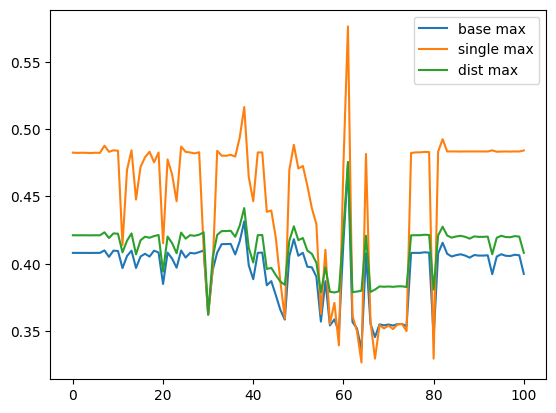

In [34]:
metric = "max" # mean, max, p95, p99, mean_top5
plt.plot(base_stats["p95"], label="base "+metric)
plt.plot(single_stats["p95"], label="single "+metric)
plt.plot(dist_stats["p95"], label="dist "+metric)
plt.legend()

print(f"Total Single Node Investment Cost: {1000 * CAPITAL_COSTS[0]:.2f}")
print(f"Total Distributed Investment Cost: {np.dot(1000*planned_dc_capacities, CAPITAL_COSTS[:num_nodes]):.2f}")

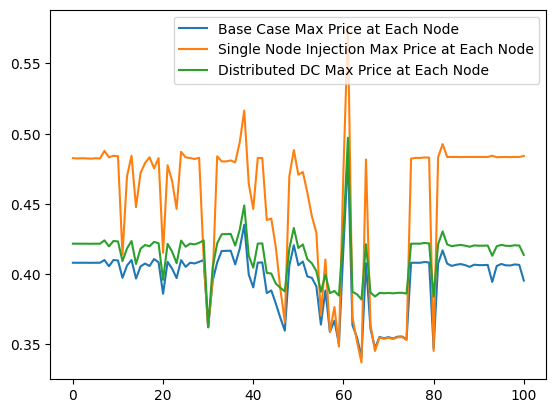

In [35]:

plt.plot(base_outcome_max_prices, label="Base Case Max Price at Each Node")
plt.plot(single_node_outcome_max_prices, label="Single Node Injection Max Price at Each Node")
plt.plot(distributed_outcome_max_prices, label="Distributed DC Max Price at Each Node")
plt.legend()

# print(np.mean(distributed_outcome_max_prices))
# print(np.mean(single_node_outcome_max_prices))

In [92]:
thr_over = 1.0  # or 0.95, whatever you used inside the objective

op_obj = zap.planning.LineOverloadObjective(
    devices=planning_devices,
    line_device_idx=3,
    line_idx=crit_idx,
    thr=thr_over,
    use_mean_over_time=False,
)

J_base   = float(op_obj(base_outcome, la=np))
J_single = float(op_obj(single_node_outcome, la=np))
J_dist   = float(op_obj(distributed_outcome, la=np))

print(f"Op metric (critical overload >= {thr_over:.2f})")
print(f"  base:   {J_base:.4f}")
print(f"  single: {J_single:.4f}")
print(f"  dist:   {J_dist:.4f}")
print(f"  single-base: {J_single - J_base:+.4f}")
print(f"  dist-base:   {J_dist - J_base:+.4f}")
print(f"  dist vs single improvement: {J_single - J_dist:+.4f}  (positive is good)")


Op metric (critical overload >= 1.00)
  base:   0.0000
  single: 0.0000
  dist:   0.0000
  single-base: +0.0000
  dist-base:   +0.0000
  dist vs single improvement: +0.0000  (positive is good)


In [93]:
thr_over = 0.90  # or 0.95, whatever you used inside the objective

op_obj = zap.planning.LineDeltaOverloadObjective(
    devices=planning_devices,
    base_line_util=base_line_util,
    line_device_idx=3,
    line_idx=crit_idx,
    thr=thr_over,
    use_mean_over_time=False,
)

J_base   = float(op_obj(base_outcome, la=np))
J_single = float(op_obj(single_node_outcome, la=np))
J_dist   = float(op_obj(distributed_outcome, la=np))

print(f"Op metric (critical overload >= {thr_over:.2f})")
print(f"  base:   {J_base:.4f}")
print(f"  single: {J_single:.4f}")
print(f"  dist:   {J_dist:.4f}")
print(f"  single-base: {J_single - J_base:+.4f}")
print(f"  dist-base:   {J_dist - J_base:+.4f}")
print(f"  dist vs single improvement: {J_single - J_dist:+.4f}  (positive is good)")


Op metric (critical overload >= 0.90)
  base:   0.0000
  single: 1.9339
  dist:   2.8917
  single-base: +1.9339
  dist-base:   +2.8917
  dist vs single improvement: -0.9577  (positive is good)


In [94]:
line_nom_caps = planned_devices[3].nominal_capacity.squeeze() # [251,]
single_node_outcome_line_flows = distributed_outcome.power[3][1] # [251, 96]

line_util = np.abs(single_node_outcome_line_flows) / line_nom_caps[:, None]  # (251, 96) utilization in [0, inf)

distributed_max_util_per_line = line_util.max(axis=1) # (251,)
distributed_mean_util_per_line = line_util.mean(axis=1) # (251,)
frac_congested = (line_util >= 1.0).mean()

print(frac_congested)

0.0


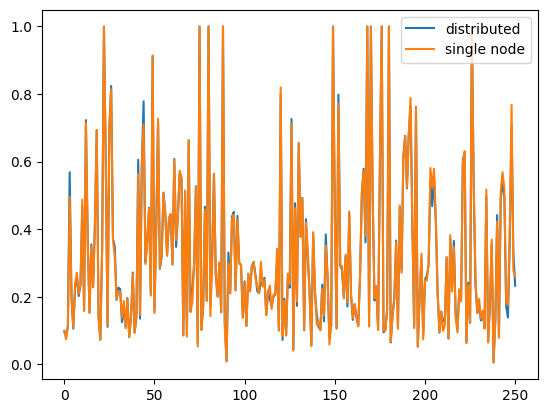

In [95]:
## Analyze line limits or something 
plt.plot(distributed_max_util_per_line, label="distributed")
plt.plot(max_util_per_line, label="single node")
plt.legend()

In [96]:
np.sum(planned_dc_capacities)

1.0

In [97]:
planning_state

({'dc_capacity': array([0.        , 0.        , 0.05408051, 0.17848102, 0.17848102,
         0.17848102, 0.        , 0.17848102, 0.17848102, 0.05351437])},
 {'loss': [array(57996.74136535),
   array(57943.04686316),
   array(57886.49863197),
   array(57884.06044556),
   array(57902.84701613),
   array(57885.46562755),
   array(57883.98852177),
   array(57904.77096862),
   array(57885.43859785),
   array(57912.97432514),
   array(57763.57768001)],
  'grad_norm': [178.4071720509089,
   533.8845936242762,
   507.0677117790757,
   148.50801968526335,
   216.53650654142234,
   3037.9735821717713,
   160.93201359685787,
   172.74805461948966,
   384.408614105514,
   1547.0856775616996,
   60951.78646688172],
  'proj_grad_norm': [178.4071720509089,
   0.11718439751815987,
   0.6493958398175695,
   0.34611199501291323,
   0.12982859656212067,
   0.08518545441959252,
   0.1987057288903229,
   0.1339371574410207,
   0.09730436559270839,
   0.2923818654408241,
   0.5280780911171337],
  'time': [2

## Run a planning experiment with Benders

In [98]:
num_nodes = 10

# ptdf_cands = [43, 45, 40, 39, 38, 18, 37, 44, 82, 52]
# new_cands = [17, 82, 83, 95, 60, 53, 56, 89, 2, 0]
# new_cands = [29, 8, 27, 2, 83, 6, 45, 82, 0, 15]
# new_cands = [29, 31, 13, 11, 56, 24, 7, 30, 20, 58]

benders_planning_devices_params_dict = {
    "num_nodes": num_nodes,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": 10, # Doesn't actually matter for planning since we optimize over it 
    "capital_costs": 0*CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}
benders_pypsa_devices_dc = create_planning_devices(pypsa_devices, benders_planning_devices_params_dict)

benders_planning_exp_params_dict = {
    "total_dc_budget": 1, # GW
    "dc_lower_bound": 0.05, # GW
    "dc_upper_bound": 0.25, # GW
    "num_iters": 10,
    "capital_cost": 0*CAPITAL_COSTS
}

benders_state = run_planning_experiment_benders(pypsa_net, pypsa_devices_dc, benders_planning_exp_params_dict)

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
{'dc_capacity': array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])}

Iter 0: LB=-0.0000, UB=2250.3828, gap=100.00%, inv=0.0000, Q=2250.3828
[0.05000036 0.0500003  0.05000046 0.0500003  0.05000019 0.0500003
 0.24999807 0.05000214 0.14999818 0.24999968]
{'dc_capacity': array([0.05000036, 0.0500003 , 0.05000046, 0.0500003 , 0.05000019,
       0.0500003 , 0.24999807, 0.05000214, 0.14999818, 0.24999968])}

Iter 1: LB=2250.0080, UB=2250.0114, gap=0.00%, inv=0.0000, Q=2250.0114
[0.05000064 0.05000049 0.05000072 0.05000045 0.05000029 0.05000044
 0.24999842 0.05000201 0.14999691 0.24999963]
{'dc_capacity': array([0.05000064, 0.05000049, 0.05000072, 0.05000045, 0.05000029,
       0.05000044, 0.24999842, 0.05000201, 0.14999691, 0.24999963])}

Iter 2: LB=2250.0114, UB=2250.0114, gap=0.00%, inv=0.0000, Q=2250.0114
Converged in 3 iterations!


In [99]:
benders_state

{'u': array([0.05000064, 0.05000049, 0.05000072, 0.05000045, 0.05000029,
        0.05000044, 0.24999842, 0.05000201, 0.14999691, 0.24999963]),
 'objective': 2250.011437713114,
 'investment_cost': 0.0,
 'dispatch_cost': 2250.0114383029204,
 'scaled_dispatch_cost': 2250.0114383029204,
 'num_iterations': 3,
 'num_cuts': 2,
 'final_gap': 1.5444236962277728e-09,
 'history': {'LB': [-1.3328820963096314e-10,
   2250.0079594148515,
   2250.011434238143],
  'UB': [2250.3828253707484, 2250.011437713114, 2250.011437713114],
  'gap': [1.0000000000000593, 1.545902480408168e-06, 1.5444236962277728e-09],
  'u': [array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]),
   array([0.05000036, 0.0500003 , 0.05000046, 0.0500003 , 0.05000019,
          0.0500003 , 0.24999807, 0.05000214, 0.14999818, 0.24999968]),
   array([0.05000064, 0.05000049, 0.05000072, 0.05000045, 0.05000029,
          0.05000044, 0.24999842, 0.05000201, 0.14999691, 0.24999963])],
  'Q': [2250.3828253707484, 2250.011437713114, 2250

In [100]:
# Simulate the dispatch outcome with the planned DC capacities
benders_planned_dc_capacities = benders_state["u"]

ptdf_cands = [43, 45, 40, 39, 38, 18, 37, 44, 82, 52]
# new_cands = [17, 82, 83, 95, 60, 53, 56, 89, 2, 0]
# new_cands = [29, 8, 27, 2, 83, 6, 45, 82, 0, 15]
new_cands = [29, 31, 13, 11, 56, 24, 7, 30, 20, 58]

benders_planning_devices_params_dict = {
    "num_nodes": num_nodes,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": benders_planned_dc_capacities, 
    "capital_costs": CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}

benders_planned_devices = create_planning_devices(pypsa_devices, benders_planning_devices_params_dict)
benders_distributed_outcome = pypsa_net.dispatch(
    benders_planned_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

<BarContainer object of 10 artists>

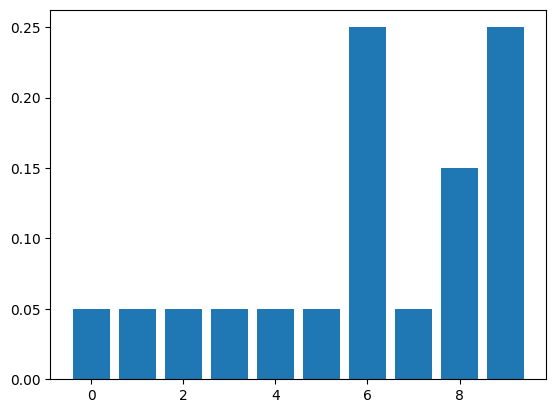

In [101]:
plt.figure()
plt.bar(range(len(benders_planned_dc_capacities)), benders_planned_dc_capacities)

In [102]:
benders_distributed_outcome_max_prices = benders_distributed_outcome.prices.max(axis=1) # [101,] (max price over time at each node)

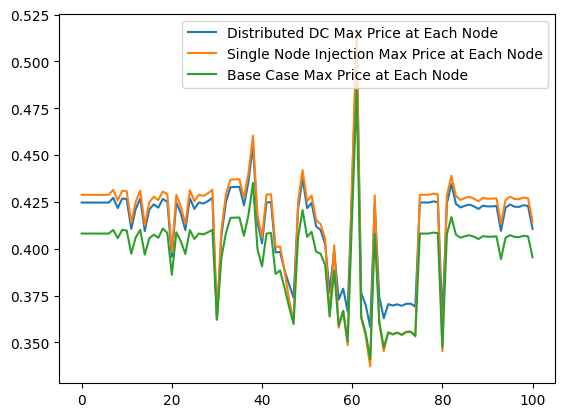

In [103]:
plt.plot(benders_distributed_outcome_max_prices, label="Distributed DC Max Price at Each Node")
plt.plot(single_node_outcome_max_prices, label="Single Node Injection Max Price at Each Node")
plt.plot(base_outcome_max_prices, label="Base Case Max Price at Each Node")
plt.legend()


Dispatch Cost before injectio   n: 2228.5776770665034
Dispatch Cost after distributed DC: 2250.0114383029204
Dispatch Cost Increased by 0.96%


<BarContainer object of 10 artists>

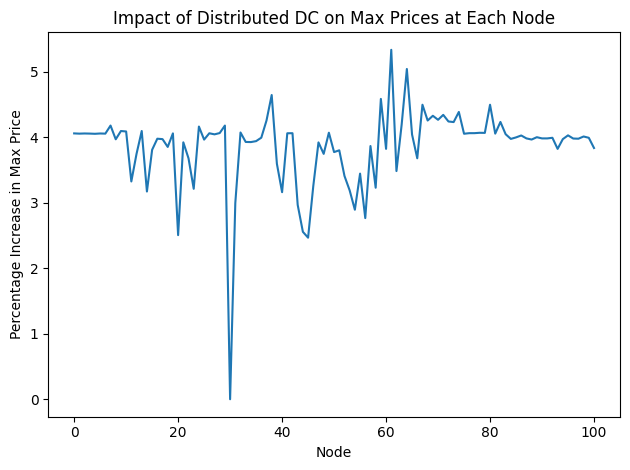

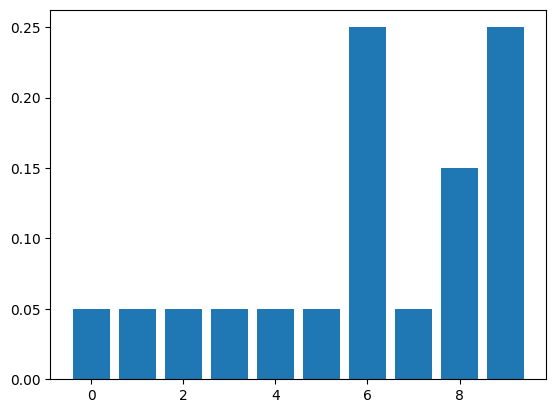

In [104]:
## Analyze results between base outcome and distributed case

base_outcome_dispatch_cost = base_outcome.problem.value
distributed_outcome_dispatch_cost = benders_distributed_outcome.problem.value

base_outcome_max_prices = base_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
distributed_outcome_max_prices = benders_distributed_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
max_prices_diff_pct = (distributed_outcome_max_prices - base_outcome_max_prices) / base_outcome_max_prices * 100 # [101,] percentage increase in max price at each node

## Observe some results from the dispatch outcome
print(f"Dispatch Cost before injectio   n: {base_outcome_dispatch_cost}")
print(f"Dispatch Cost after distributed DC: {distributed_outcome_dispatch_cost}")
print(f"Dispatch Cost Increased by {(distributed_outcome_dispatch_cost - base_outcome_dispatch_cost)/base_outcome_dispatch_cost * 100:.2f}%")

injection_terminal = INVESTMENT_NODE_CANDS[0]
plt.plot(max_prices_diff_pct, label="Percentage Increase in Max Price at Each Node")
plt.xlabel("Node")
plt.ylabel("Percentage Increase in Max Price")
plt.title("Impact of Distributed DC on Max Prices at Each Node")
plt.tight_layout()


plt.figure()
plt.bar(range(len(benders_planned_dc_capacities)), benders_planned_dc_capacities)

In [105]:
line_nom_caps = benders_planned_devices[3].nominal_capacity.squeeze() # [251,]
single_node_outcome_line_flows = benders_distributed_outcome.power[3][1] # [251, 96]

line_util = np.abs(single_node_outcome_line_flows) / line_nom_caps[:, None]  # (251, 96) utilization in [0, inf)

In [106]:
line_util_diff = single_node_line_util - line_util


In [107]:
U1 = np.asarray(single_node_line_util)
U2 = np.asarray(line_util)
D  = np.asarray(line_util_diff)

assert U1.shape == U2.shape == D.shape, f"Shape mismatch: {U1.shape}, {U2.shape}, {D.shape}"
L, T = U1.shape

# 1) Global max absolute diff
max_abs = float(np.max(np.abs(D)))

# 2) Per-line max abs diff over time
per_line_max = np.max(np.abs(D), axis=1)              # [L]
topk = min(10, L)
top_lines = np.argsort(per_line_max)[::-1][:topk]     # largest diffs

# 3) Per-time max abs diff across lines
per_time_max = np.max(np.abs(D), axis=0)              # [T]

# 4) Bottleneck identity over time (which line is most utilized each hour)
argmax1 = np.argmax(U1, axis=0)   # [T]
argmax2 = np.argmax(U2, axis=0)   # [T]
same_argmax_frac = float(np.mean(argmax1 == argmax2))

# 5) Relative Frobenius norm of the difference
fro_rel = float(np.linalg.norm(D) / (np.linalg.norm(U1) + 1e-12))

print("=== Line utilization comparison ===")
print(f"Shape [L,T] = [{L},{T}]")
print(f"max |single - dist| = {max_abs:.3e}")
print(f"relative Frobenius ||diff||/||single|| = {fro_rel:.3e}")
print(f"argmax(line util) matches fraction over time = {same_argmax_frac:.3f}")

print("\nTop lines by max abs diff over time:")
for k, ell in enumerate(top_lines, 1):
    print(f"{k:2d}) line {int(ell):3d}  max|diff|={per_line_max[ell]:.3e}  "
          f"mean(diff)={np.mean(D[ell]):+.3e}  std(diff)={np.std(D[ell]):.3e}")

print("\nPer-time max abs diff across lines (summary):")
print(f"min={np.min(per_time_max):.3e}, median={np.median(per_time_max):.3e}, max={np.max(per_time_max):.3e}")
print(f"hours with max_abs_diff > 1e-3: {int(np.sum(per_time_max > 1e-3))}/{T}")

# Optional: if you want to see which line is the bottleneck each hour (first 20 hours)
print("\nFirst 20 hours argmax line indices (single vs dist):")
print("single:", argmax1[:20].tolist())
print("dist:  ", argmax2[:20].tolist())

=== Line utilization comparison ===
Shape [L,T] = [251,96]
max |single - dist| = 4.230e-01
relative Frobenius ||diff||/||single|| = 7.154e-02
argmax(line util) matches fraction over time = 0.792

Top lines by max abs diff over time:
 1) line 176  max|diff|=4.230e-01  mean(diff)=-5.657e-02  std(diff)=1.280e-01
 2) line 168  max|diff|=2.999e-01  mean(diff)=+2.994e-02  std(diff)=7.251e-02
 3) line  88  max|diff|=2.274e-01  mean(diff)=+2.846e-03  std(diff)=6.080e-02
 4) line  64  max|diff|=1.578e-01  mean(diff)=-2.632e-02  std(diff)=4.756e-02
 5) line  94  max|diff|=1.523e-01  mean(diff)=-1.763e-02  std(diff)=4.822e-02
 6) line  49  max|diff|=1.475e-01  mean(diff)=-2.562e-02  std(diff)=4.405e-02
 7) line 107  max|diff|=1.443e-01  mean(diff)=+9.030e-03  std(diff)=3.131e-02
 8) line 106  max|diff|=1.385e-01  mean(diff)=-8.990e-03  std(diff)=4.501e-02
 9) line  43  max|diff|=1.294e-01  mean(diff)=-3.378e-02  std(diff)=3.581e-02
10) line  96  max|diff|=1.280e-01  mean(diff)=-9.856e-03  std(dif

In [108]:
# Transmission relief diagnostics (utilization-based), using your variables:
#   single_node_line_util: [L, T]
#   line_util:             [L, T]
#   line_util_diff = single_node_line_util - line_util  (positive => distributed relieves)

import numpy as np

U_single = np.asarray(single_node_line_util)   # [L,T]
U_dist   = np.asarray(line_util)               # [L,T]
D        = np.asarray(line_util_diff)          # [L,T]  = U_single - U_dist

assert U_single.shape == U_dist.shape == D.shape
L, T = D.shape

# --- Per-line metrics ---
mean_diff = np.mean(D, axis=1)                          # avg relief (signed)
max_relief = np.max(D, axis=1)                          # best hour relief (>=0 if ever relieved)
max_stress = np.min(D, axis=1)                          # worst hour (<=0 if ever worse)
frac_relief = np.mean(D > 0, axis=1)                    # fraction of hours relieved

mean_relief = np.sum(np.maximum(D, 0.0), axis=1) / T    # avg positive part
mean_stress = np.sum(np.maximum(-D, 0.0), axis=1) / T   # avg negative part

# Peak utilization change (planning-relevant)
peak_single = np.max(U_single, axis=1)
peak_dist   = np.max(U_dist, axis=1)
peak_relief = peak_single - peak_dist                   # positive => dist reduces peak utilization

# "Near-binding" hours (change threshold as you like)
thr = 0.90
nearbind_single = np.mean(U_single >= thr, axis=1)
nearbind_dist   = np.mean(U_dist   >= thr, axis=1)
nearbind_delta  = nearbind_single - nearbind_dist       # positive => dist reduces near-binding frequency

# --- Sort / print helpers ---
def print_top(title, score, k=10, extra=None):
    idx = np.argsort(score)[::-1][:k]
    print(f"\n=== {title} (top {k}) ===")
    for r, ell in enumerate(idx, 1):
        parts = [
            f"{r:2d}) line {int(ell):3d}",
            f"score={score[ell]:+.4f}",
        ]
        if extra is not None:
            for name, arr, fmt in extra:
                parts.append(f"{name}={fmt(arr[ell])}")
        print("  " + "  ".join(parts))

# Top lines where distribution most reduces PEAK utilization
print_top(
    "Peak utilization relief: peak(single) - peak(dist)  [positive is good]",
    peak_relief,
    k=10,
    extra=[
        ("peak_single", peak_single, lambda x: f"{x:.3f}"),
        ("peak_dist", peak_dist, lambda x: f"{x:.3f}"),
        ("frac_relief", frac_relief, lambda x: f"{x:.2f}"),
        ("max_relief", max_relief, lambda x: f"{x:+.3f}"),
        ("max_stress", max_stress, lambda x: f"{x:+.3f}"),
    ],
)

# Top lines where distribution most INCREASES peak utilization (bad)
print_top(
    "Peak utilization stress: peak(dist) - peak(single)  [positive is bad]",
    -peak_relief,
    k=10,
    extra=[
        ("peak_single", peak_single, lambda x: f"{x:.3f}"),
        ("peak_dist", peak_dist, lambda x: f"{x:.3f}"),
        ("frac_relief", frac_relief, lambda x: f"{x:.2f}"),
        ("max_relief", max_relief, lambda x: f"{x:+.3f}"),
        ("max_stress", max_stress, lambda x: f"{x:+.3f}"),
    ],
)

# Top lines by average relief (signed mean diff)
print_top(
    "Average utilization relief: mean(single - dist)  [positive is good]",
    mean_diff,
    k=10,
    extra=[
        ("mean_relief", mean_relief, lambda x: f"{x:.3f}"),
        ("mean_stress", mean_stress, lambda x: f"{x:.3f}"),
        ("frac_relief", frac_relief, lambda x: f"{x:.2f}"),
        ("max_relief", max_relief, lambda x: f"{x:+.3f}"),
        ("max_stress", max_stress, lambda x: f"{x:+.3f}"),
    ],
)

# Top lines where distribution most reduces time spent near-binding (>= thr)
print_top(
    f"Near-binding frequency relief at util>={thr:.2f}: P(single>=thr)-P(dist>=thr)  [positive is good]",
    nearbind_delta,
    k=10,
    extra=[
        ("nearbind_single", nearbind_single, lambda x: f"{x:.2f}"),
        ("nearbind_dist", nearbind_dist, lambda x: f"{x:.2f}"),
        ("peak_relief", peak_relief, lambda x: f"{x:+.3f}"),
    ],
)

# Global summaries
print("\n=== Global summaries ===")
print(f"Mean over lines of peak_relief: {np.mean(peak_relief):+.4f}")
print(f"Fraction of lines with peak_relief>0 (peak relieved): {np.mean(peak_relief > 0):.3f}")
print(f"Fraction of lines with mean_diff>0 (avg relieved): {np.mean(mean_diff > 0):.3f}")
print(f"Avg frac_relief across lines: {np.mean(frac_relief):.3f}")
print(f"Total near-binding hours (util>={thr:.2f}) single: {np.sum(U_single >= thr)}")
print(f"Total near-binding hours (util>={thr:.2f}) dist:   {np.sum(U_dist   >= thr)}")



=== Peak utilization relief: peak(single) - peak(dist)  [positive is good] (top 10) ===
   1) line 248  score=+0.0739  peak_single=0.768  peak_dist=0.694  frac_relief=0.89  max_relief=+0.124  max_stress=-0.059
   2) line 120  score=+0.0564  peak_single=0.820  peak_dist=0.763  frac_relief=0.88  max_relief=+0.104  max_stress=-0.070
   3) line 109  score=+0.0467  peak_single=0.304  peak_dist=0.257  frac_relief=0.77  max_relief=+0.066  max_stress=-0.031
   4) line 247  score=+0.0372  peak_single=0.404  peak_dist=0.367  frac_relief=0.92  max_relief=+0.048  max_stress=-0.022
   5) line  10  score=+0.0350  peak_single=0.487  peak_dist=0.452  frac_relief=0.58  max_relief=+0.080  max_stress=-0.072
   6) line  42  score=+0.0323  peak_single=0.146  peak_dist=0.114  frac_relief=0.58  max_relief=+0.061  max_stress=-0.026
   7) line 114  score=+0.0316  peak_single=0.233  peak_dist=0.201  frac_relief=0.77  max_relief=+0.045  max_stress=-0.021
   8) line 250  score=+0.0272  peak_single=0.259  peak_di

In [109]:
# Critical-line-only transmission relief summary
# Uses your arrays:
#   single_node_line_util: [L,T]
#   line_util:             [L,T]

import numpy as np

U_single = np.asarray(single_node_line_util)  # [L,T]
U_dist   = np.asarray(line_util)              # [L,T]
assert U_single.shape == U_dist.shape
L, T = U_single.shape

# Diff: positive => distributed relieves
D = U_single - U_dist

# --- Define "critical lines" from the single-node case ---
thr_peak = 0.90  # change if you want (0.95 is stricter)
peak_single = np.max(U_single, axis=1)
crit_mask = peak_single >= thr_peak
crit_idx = np.where(crit_mask)[0]
ncrit = crit_idx.size

print(f"Critical lines = peak_single >= {thr_peak:.2f}: {ncrit}/{L} lines")

if ncrit == 0:
    print("No critical lines at this threshold. Lower thr_peak (e.g., 0.80) or use top-K.")
else:
    # Slice to critical set
    Us = U_single[crit_idx]
    Ud = U_dist[crit_idx]
    Dc = D[crit_idx]
    peak_s = np.max(Us, axis=1)
    peak_d = np.max(Ud, axis=1)
    peak_relief = peak_s - peak_d  # positive => peak relieved

    # Near-binding frequency on critical lines (optional)
    thr_near = 0.90
    near_s = np.mean(Us >= thr_near, axis=1)
    near_d = np.mean(Ud >= thr_near, axis=1)
    near_delta = near_s - near_d   # positive => fewer near-binding hours

    # Overload proxy above a threshold (planning-relevant)
    thr_over = 0.95
    over_s = np.maximum(Us - thr_over, 0.0)
    over_d = np.maximum(Ud - thr_over, 0.0)
    over_peak_s = np.max(over_s, axis=1)
    over_peak_d = np.max(over_d, axis=1)
    over_peak_delta = over_peak_s - over_peak_d  # positive => reduces worst overload margin

    over_energy_s = np.sum(over_s, axis=1) / T    # avg overload above thr_over
    over_energy_d = np.sum(over_d, axis=1) / T
    over_energy_delta = over_energy_s - over_energy_d

    # Signed average diff on critical lines
    mean_diff = np.mean(Dc, axis=1)
    frac_relief = np.mean(Dc > 0, axis=1)

    # --- Summary (critical only) ---
    print("\n=== Critical-line summaries (single-node defines critical set) ===")
    print(f"Mean peak_single: {np.mean(peak_s):.3f}   Mean peak_dist: {np.mean(peak_d):.3f}")
    print(f"Mean peak_relief (peak_single-peak_dist): {np.mean(peak_relief):+.4f}")
    print(f"Frac critical lines with peak_relief>0:    {np.mean(peak_relief > 0):.3f}")

    print(f"\nNear-binding (util>={thr_near:.2f}) on critical lines:")
    print(f"  Total near-binding hours single: {int(np.sum(Us >= thr_near))}")
    print(f"  Total near-binding hours dist:   {int(np.sum(Ud >= thr_near))}")
    print(f"  Mean per-line nearbind freq single: {np.mean(near_s):.3f}")
    print(f"  Mean per-line nearbind freq dist:   {np.mean(near_d):.3f}")
    print(f"  Mean nearbind relief (single-dist): {np.mean(near_delta):+.4f}")
    print(f"  Frac critical lines with nearbind relief>0: {np.mean(near_delta > 0):.3f}")

    print(f"\nOverload proxy above {thr_over:.2f} (only counts util beyond threshold):")
    print(f"  Total overload (avg over time, summed over crit lines) single: {float(np.sum(over_energy_s)):.4f}")
    print(f"  Total overload (avg over time, summed over crit lines) dist:   {float(np.sum(over_energy_d)):.4f}")
    print(f"  Total overload relief (single-dist):                           {float(np.sum(over_energy_delta)):+.4f}")
    print(f"  Mean per-line overload relief (single-dist):                   {float(np.mean(over_energy_delta)):+.4f}")
    print(f"  Frac critical lines with overload relief>0:                    {np.mean(over_energy_delta > 0):.3f}")
    print(f"  Mean peak overload margin single: {np.mean(over_peak_s):.4f}  dist: {np.mean(over_peak_d):.4f}")
    print(f"  Mean peak overload relief (single-dist): {np.mean(over_peak_delta):+.4f}")

    # --- Show top-K critical lines where distribution helps/hurts peaks ---
    k = min(10, ncrit)

    help_idx = crit_idx[np.argsort(peak_relief)[::-1][:k]]
    hurt_idx = crit_idx[np.argsort(peak_relief)[:k]]

    def line_row(ell):
        ds = D[ell]
        return (
            f"line {ell:3d} | peak_single={np.max(U_single[ell]):.3f} peak_dist={np.max(U_dist[ell]):.3f} "
            f"peak_relief={np.max(U_single[ell])-np.max(U_dist[ell]):+.3f} "
            f"mean_diff={np.mean(ds):+.3f} frac_relief={np.mean(ds>0):.2f} "
            f"max_relief={np.max(ds):+.3f} max_stress={np.min(ds):+.3f}"
        )

    print(f"\nTop {k} critical lines by PEAK relief (best):")
    for ell in help_idx:
        print("  " + line_row(int(ell)))

    print(f"\nTop {k} critical lines by PEAK stress (worst):")
    for ell in hurt_idx:
        print("  " + line_row(int(ell)))


Critical lines = peak_single >= 0.90: 11/251 lines

=== Critical-line summaries (single-node defines critical set) ===
Mean peak_single: 0.992   Mean peak_dist: 0.992
Mean peak_relief (peak_single-peak_dist): -0.0007
Frac critical lines with peak_relief>0:    0.000

Near-binding (util>=0.90) on critical lines:
  Total near-binding hours single: 600
  Total near-binding hours dist:   604
  Mean per-line nearbind freq single: 0.568
  Mean per-line nearbind freq dist:   0.572
  Mean nearbind relief (single-dist): -0.0038
  Frac critical lines with nearbind relief>0: 0.182

Overload proxy above 0.95 (only counts util beyond threshold):
  Total overload (avg over time, summed over crit lines) single: 0.2658
  Total overload (avg over time, summed over crit lines) dist:   0.2749
  Total overload relief (single-dist):                           -0.0091
  Mean per-line overload relief (single-dist):                   -0.0008
  Frac critical lines with overload relief>0:                    0.364

In [110]:
import numpy as np

# -----------------------------
# Set these to your variables
# -----------------------------
outcome_single = single_node_outcome
outcome_dist   = benders_distributed_outcome
devices        = pypsa_devices_dc   # list of zap devices used in the solve, aligned with outcome.power indexing

# -----------------------------
# Helpers to robustly extract arrays from outcome.power entries
# -----------------------------
def _as_ndarray(x):
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        return x
    try:
        return np.asarray(x)
    except Exception:
        return None

def extract_power_entry(power_entry):
    """
    Returns a numpy array shaped [n, T] if it can find one inside power_entry,
    else returns None.
    Works if power_entry is:
      - ndarray
      - list/tuple containing an ndarray
      - dict with an ndarray value
    """
    if power_entry is None:
        return None

    if isinstance(power_entry, np.ndarray):
        return power_entry

    if isinstance(power_entry, (list, tuple)):
        # pick the first array-like thing with 2 dims
        candidates = []
        for item in power_entry:
            arr = _as_ndarray(item)
            if arr is not None and arr.ndim == 2:
                candidates.append(arr)
        if candidates:
            return candidates[0]
        # sometimes it's 1d (e.g., per-time) -- keep as fallback
        for item in power_entry:
            arr = _as_ndarray(item)
            if arr is not None and arr.ndim == 1:
                return arr[None, :]  # treat as [1,T]
        return None

    if isinstance(power_entry, dict):
        for v in power_entry.values():
            arr = _as_ndarray(v)
            if arr is not None and arr.ndim == 2:
                return arr
        return None

    arr = _as_ndarray(power_entry)
    if arr is not None:
        if arr.ndim == 2:
            return arr
        if arr.ndim == 1:
            return arr[None, :]
    return None

def is_transmission_device(dev):
    name = type(dev).__name__.lower()
    return ("line" in name) or ("acline" in name) or ("dcline" in name) or ("transporter" in name)

def is_load_device(dev):
    name = type(dev).__name__.lower()
    return ("load" in name) or ("demand" in name)

def looks_like_generator(dev):
    name = type(dev).__name__.lower()
    # common heuristics: has cost attribute + capacity-ish attribute; not a line/load
    has_cost = any(hasattr(dev, a) for a in ["linear_cost", "marginal_cost", "cost"])
    has_cap  = any(hasattr(dev, a) for a in ["capacity", "nominal_capacity", "p_nom", "dynamic_capacity"])
    return (not is_transmission_device(dev)) and (not is_load_device(dev)) and has_cost and has_cap

def get_cost_vector(dev):
    """
    Returns a 1d cost vector per generator element if possible (shape [n]),
    otherwise None.
    """
    for attr in ["linear_cost", "marginal_cost", "cost"]:
        if hasattr(dev, attr):
            c = _as_ndarray(getattr(dev, attr))
            if c is None:
                continue
            # often [n, T] or [n,1] or [n]
            if c.ndim == 2:
                # if time-varying, just keep full matrix; we’ll handle later
                return c
            if c.ndim == 1:
                return c
    return None

def get_cap_matrix(dev, T):
    """
    Returns a capacity matrix [n, T] if possible, otherwise None.
    """
    # Try time-varying capacity first
    for attr in ["dynamic_capacity", "capacity"]:
        if hasattr(dev, attr):
            cap = _as_ndarray(getattr(dev, attr))
            if cap is None:
                continue
            if cap.ndim == 2:
                # could be [n,T] already
                if cap.shape[1] == T:
                    return cap
                # could be [n,1]
                if cap.shape[1] == 1:
                    return np.repeat(cap, T, axis=1)
            if cap.ndim == 1:
                return np.repeat(cap[:, None], T, axis=1)

    # Try nominal capacity style + maybe capacity factors
    for attr in ["nominal_capacity", "p_nom"]:
        if hasattr(dev, attr):
            nom = _as_ndarray(getattr(dev, attr))
            if nom is None:
                continue
            if nom.ndim == 2 and nom.shape[1] == 1:
                nom = nom[:, 0]
            if nom.ndim == 1:
                return np.repeat(nom[:, None], T, axis=1)

    return None

# -----------------------------
# Identify generator-like devices and extract their dispatch matrices
# -----------------------------
P_single_list = []
P_dist_list   = []
gen_meta = []   # (device_index, local_row_offset, n_rows, device_type)

# We’ll concatenate multiple generator devices if you have them.
row_offset = 0
for i, dev in enumerate(devices):
    if not looks_like_generator(dev):
        continue

    P1 = extract_power_entry(outcome_single.power[i])
    P2 = extract_power_entry(outcome_dist.power[i])

    if P1 is None or P2 is None:
        continue
    if P1.shape != P2.shape:
        print(f"[warn] device {i} ({type(dev).__name__}) power shape mismatch: {P1.shape} vs {P2.shape}")
        continue
    if P1.ndim != 2:
        continue

    n, T = P1.shape
    P_single_list.append(P1)
    P_dist_list.append(P2)
    gen_meta.append((i, row_offset, n, type(dev).__name__))
    row_offset += n

if not P_single_list:
    raise RuntimeError("Couldn't find any generator-like devices / power matrices. "
                       "You may need to adjust looks_like_generator() or point me to the generator device index.")

Pg_single = np.vstack(P_single_list)  # [G,T]
Pg_dist   = np.vstack(P_dist_list)    # [G,T]
dPg       = Pg_dist - Pg_single
G, T = Pg_single.shape

print(f"Found generator dispatch matrix: Pg shape = [{G},{T}] (concatenated across {len(gen_meta)} device blocks)")

# -----------------------------
# Core “why cost isn’t moving” diagnostics
# -----------------------------
print("\n=== Dispatch change magnitude ===")
print(f"max |dPg|: {np.max(np.abs(dPg)):.3e}")
print(f"mean |dPg|: {np.mean(np.abs(dPg)):.3e}")
print(f"||dPg||_F / ||Pg_single||_F: {np.linalg.norm(dPg) / (np.linalg.norm(Pg_single) + 1e-12):.3e}")

# Per-generator energy change (sum over time)
dE = np.sum(dPg, axis=1)                 # [G]
abs_dE = np.abs(dE)
topk = min(15, G)
top_g = np.argsort(abs_dE)[::-1][:topk]

print("\nTop generators by |sum_t dPg| (energy shift):")
for k, g in enumerate(top_g, 1):
    print(f"{k:2d}) gen {g:4d}: sum(dPg)={dE[g]:+.4e},  max|dPg|={np.max(np.abs(dPg[g])):.3e},  mean|dPg|={np.mean(np.abs(dPg[g])):.3e}")

# -----------------------------
# Binding-to-capacity analysis (if we can infer pmax)
# -----------------------------
# Build a concatenated cap matrix if possible
cap_blocks = []
for (dev_idx, row0, n, devname), dev in zip(gen_meta, [devices[m[0]] for m in gen_meta]):
    # cap matrix for this device block
    cap = get_cap_matrix(dev, T)
    if cap is None:
        cap_blocks = None
        break
    if cap.shape[0] != n or cap.shape[1] != T:
        print(f"[warn] capacity shape mismatch for device {dev_idx} ({devname}): {cap.shape} expected ({n},{T})")
        cap_blocks = None
        break
    cap_blocks.append(cap)

if cap_blocks is not None:
    Pmax = np.vstack(cap_blocks)  # [G,T]
    eps = 1e-6

    bind_single = Pg_single >= (Pmax - eps)
    bind_dist   = Pg_dist   >= (Pmax - eps)

    bind_rate_single = np.mean(bind_single)
    bind_rate_dist   = np.mean(bind_dist)

    print("\n=== Binding to pmax (approx) ===")
    print(f"Overall binding rate single: {bind_rate_single:.3f}")
    print(f"Overall binding rate dist:   {bind_rate_dist:.3f}")
    print(f"Delta (dist - single):       {(bind_rate_dist - bind_rate_single):+.3f}")

    # Per-generator binding frequency change
    b1 = np.mean(bind_single, axis=1)
    b2 = np.mean(bind_dist, axis=1)
    db = b2 - b1

    top_bind = np.argsort(db)[::-1][:10]     # increased binding in dist (bad)
    top_rel  = np.argsort(db)[:10]           # decreased binding in dist (good)

    print("\nGenerators with MOST increased pmax-binding in distributed (bad):")
    for g in top_bind:
        print(f"gen {g:4d}: bind_single={b1[g]:.2f}, bind_dist={b2[g]:.2f}, delta={db[g]:+.2f}")

    print("\nGenerators with MOST decreased pmax-binding in distributed (good):")
    for g in top_rel:
        print(f"gen {g:4d}: bind_single={b1[g]:.2f}, bind_dist={b2[g]:.2f}, delta={db[g]:+.2f}")
else:
    print("\n[info] Could not infer generator capacity matrix (pmax) from device attributes; skipping binding analysis.")

# -----------------------------
# Cost decomposition (if we can infer linear costs)
# -----------------------------
# Concatenate per-generator marginal costs if available (supports time-varying too)
cost_blocks = []
time_varying_cost = False

for (dev_idx, row0, n, devname), dev in zip(gen_meta, [devices[m[0]] for m in gen_meta]):
    c = get_cost_vector(dev)
    if c is None:
        cost_blocks = None
        break
    c = _as_ndarray(c)
    if c.ndim == 2:
        time_varying_cost = True
        if c.shape != (n, T) and c.shape != (n, 1):
            print(f"[warn] cost matrix shape unexpected for device {dev_idx} ({devname}): {c.shape}")
            cost_blocks = None
            break
        if c.shape[1] == 1:
            c = np.repeat(c, T, axis=1)
        cost_blocks.append(c)
    elif c.ndim == 1:
        if c.shape[0] != n:
            print(f"[warn] cost vector shape unexpected for device {dev_idx} ({devname}): {c.shape}")
            cost_blocks = None
            break
        cost_blocks.append(np.repeat(c[:, None], T, axis=1))
    else:
        cost_blocks = None
        break

if cost_blocks is not None:
    C = np.vstack(cost_blocks)  # [G,T] marginal cost
    # dispatch cost proxy (linear): sum c * p (assuming dt=1)
    cost_single = float(np.sum(C * Pg_single))
    cost_dist   = float(np.sum(C * Pg_dist))
    print("\n=== Linear dispatch cost proxy from generator blocks ===")
    print(f"cost_single (gen-sum): {cost_single:.6f}")
    print(f"cost_dist   (gen-sum): {cost_dist:.6f}")
    print(f"delta (dist - single): {cost_dist - cost_single:+.6f}")

    # Which gens contribute most to cost delta?
    dCost_g = np.sum(C * dPg, axis=1)  # [G]
    top_cost = np.argsort(np.abs(dCost_g))[::-1][:15]
    print("\nTop generators by |delta cost| contribution (c * dPg):")
    for k, g in enumerate(top_cost, 1):
        print(f"{k:2d}) gen {g:4d}: dCost={dCost_g[g]:+.4e},  sum(dPg)={dE[g]:+.4e},  mean(c)={np.mean(C[g]):.3e}")
else:
    print("\n[info] Could not infer generator marginal costs from device attributes; skipping cost decomposition.")


Found generator dispatch matrix: Pg shape = [408,96] (concatenated across 1 device blocks)

=== Dispatch change magnitude ===
max |dPg|: 1.653e+00
mean |dPg|: 2.916e-03
||dPg||_F / ||Pg_single||_F: 4.769e-02

Top generators by |sum_t dPg| (energy shift):
 1) gen  332: sum(dPg)=-1.6271e+01,  max|dPg|=1.266e+00,  mean|dPg|=1.695e-01
 2) gen  272: sum(dPg)=+1.0113e+01,  max|dPg|=8.658e-01,  mean|dPg|=1.053e-01
 3) gen  242: sum(dPg)=-7.7574e+00,  max|dPg|=1.001e+00,  mean|dPg|=1.195e-01
 4) gen   65: sum(dPg)=+5.8246e+00,  max|dPg|=5.802e-01,  mean|dPg|=6.067e-02
 5) gen  269: sum(dPg)=+5.7978e+00,  max|dPg|=1.653e+00,  mean|dPg|=1.134e-01
 6) gen  283: sum(dPg)=+5.7286e+00,  max|dPg|=1.334e+00,  mean|dPg|=6.231e-02
 7) gen  257: sum(dPg)=-3.9737e+00,  max|dPg|=1.113e+00,  mean|dPg|=5.014e-02
 8) gen  107: sum(dPg)=+3.8076e+00,  max|dPg|=3.851e-01,  mean|dPg|=3.966e-02
 9) gen   28: sum(dPg)=-3.1232e+00,  max|dPg|=4.371e-01,  mean|dPg|=6.567e-02
10) gen   83: sum(dPg)=+2.8466e+00,  max|dP